# 1주차 코드과제
- **코드과제 1**: MNIST Digit Classification with CNN
- **코드과제 2**: Object Detection 실습 — YOLOv1 구현하기

---
# 코드과제 1

# MNIST Digit Classification with Convolutional Neural Network (CNN)

**Discipline(s):** Computer Vision, Deep Learning

colab에서 돌릴 경우, 런타임 유형을 GPU로 변경해주세요.

## 1. Import Statements

---



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

## 2. Data Preprocessing

---



The first step is to preprocess our data.

In [10]:
# 하이퍼 파라미터 설정
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
    # 0.1307 , 0.3081은 MNIST 전체 픽셀의 평균 & 표준편차
])

In [4]:
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.39MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.1MB/s]


In [5]:
# train, test셋 배정
X_train = train_dataset.data
y_train = train_dataset.targets
X_test = test_dataset.data
y_test = test_dataset.targets

print("Training Images:", X_train.shape)  # [60000, 28, 28]
print("Testing Images:", X_test.shape)    # [10000, 28, 28]
print("Training Labels:", y_train.shape)  # [60000]
print("Test Labels:", y_test.shape)       # [10000]

Training Images: torch.Size([60000, 28, 28])
Testing Images: torch.Size([10000, 28, 28])
Training Labels: torch.Size([60000])
Test Labels: torch.Size([10000])


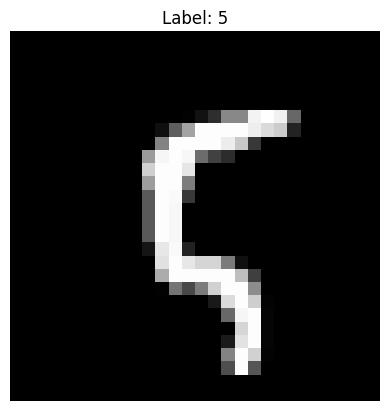

In [8]:
plt.imshow(X_train[100], cmap='gray')
plt.title(f"Label: {y_train[100].item()}")
plt.axis('off')
plt.show()

## 3. Convolutional Neural Network (CNN)

---



### 3.1. Define the Model

We then have to define our convolutional neural network.

In [11]:
# CNN 모델 정의 -> 차원이 어떻게 될지 생각하면서 코드 빈칸을 채워주세요.
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # 흑백이니깐 채널 1개, 필터 32개, 커널 3*3, stride = 1, padding 1칸
            # 1,28,28 -> 패딩하면 1,30,30 -> 커널 거치면 32,28,28 (패딩 = 1에 stride =1이니깐 원상복귀)
            nn.Conv2d(in_channels = 1, out_channels = 32, kernel_size = 3, stride = 1, padding = 1),
            # activation function 활성화 함수는 ReLU로
            nn.ReLU(), # 각각 요소 단위로
            nn.MaxPool2d(kernel_size=2), # 2*2 씩 MaxPooling -> 32*14*14

            # 모델을 더 깊게 쌓아도 됩니다.

            # fully connected layer 전, flatten 과정 필요 -> 길게 쭉 펴야지
            nn.Flatten(), # [64, 32*14*14]
            nn.Linear(32*14*14, 128),
            nn.ReLU(),
            nn.Linear(128, 10) # 0~9까지니까 10개
        )

    def forward(self, x):
        return self.net(x)

In [12]:
# 모델 준비
model = SimpleCNN().to(DEVICE)

Once our model is defined, we can compile it using the Adam optimizer and the categorical cross-entropy loss function.

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

### 3.2. Train the Model

In [15]:
def train(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        correct += (output.argmax(dim=1) == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [16]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            output = model(x)
            loss = criterion(output, y)

            total_loss += loss.item() * y.size(0)
            correct += (output.argmax(dim=1) == y).sum().item()
            total += y.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [17]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader)
    test_loss, test_acc = evaluate(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"[Epoch {epoch+1}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

[Epoch 1] Train Loss: 0.1466, Train Acc: 0.9547 | Test Loss: 0.0573, Test Acc: 0.9802
[Epoch 2] Train Loss: 0.0532, Train Acc: 0.9830 | Test Loss: 0.0520, Test Acc: 0.9817
[Epoch 3] Train Loss: 0.0335, Train Acc: 0.9892 | Test Loss: 0.0471, Test Acc: 0.9849
[Epoch 4] Train Loss: 0.0216, Train Acc: 0.9930 | Test Loss: 0.0596, Test Acc: 0.9829
[Epoch 5] Train Loss: 0.0151, Train Acc: 0.9950 | Test Loss: 0.0472, Test Acc: 0.9868


### 3.3. 시각화

Finally, we can plot the curves.

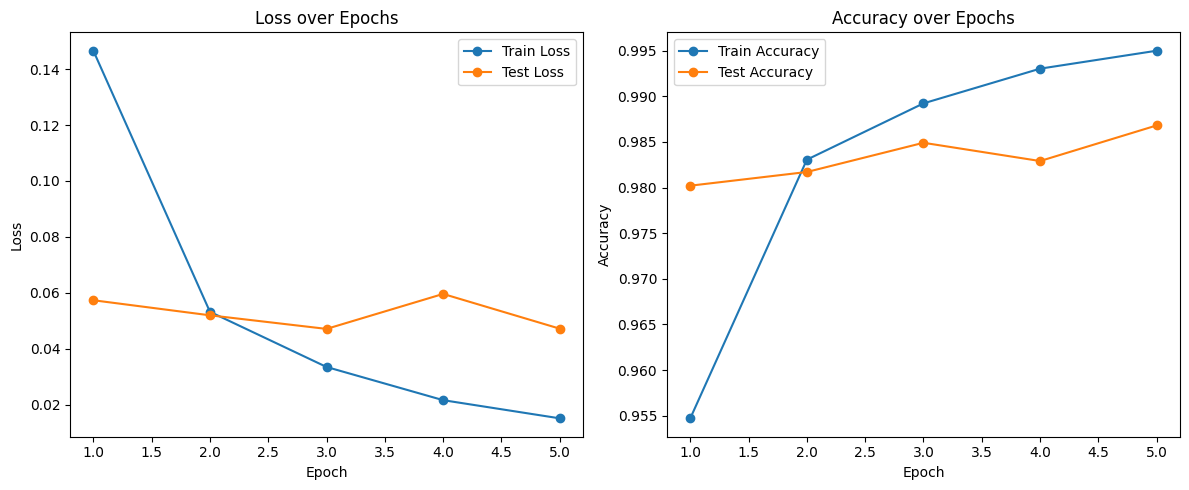

In [18]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, test_losses, label='Test Loss', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs, test_accuracies, label='Test Accuracy', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

## 4. Make a Prediction

---



Once our model is trained, we can use it to make predictions. To do this, we first use our test set to predict the classes.

In [19]:
def show_random_predictions(model, dataset, num_images=5):
    model.eval()

    indices = random.sample(range(len(dataset)), num_images)
    images = torch.stack([dataset[i][0] for i in indices])
    labels = torch.tensor([dataset[i][1] for i in indices])

    images = images.to(DEVICE)
    outputs = model(images)
    preds = outputs.argmax(dim=1)

    plt.figure(figsize=(12, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.title(f"GT: {labels[i].item()}\nPred: {preds[i].item()}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Finally, we can show a random test image with its corresponding prediction.

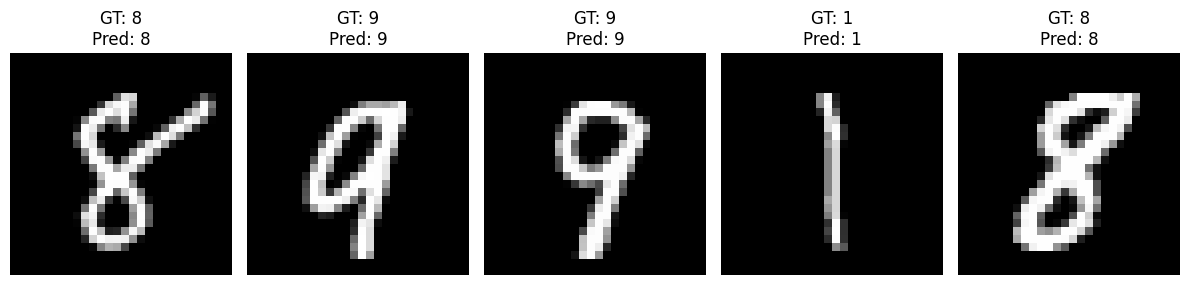

In [20]:
show_random_predictions(model, test_dataset, num_images=5)

## ResNet

In [21]:
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [22]:
class ResidualBlock(nn.Module): # ResidualBlock은 ResNetLike 안에 들어가서 in_channels, out_channels 받아야 함
    def __init__(self, in_channels, out_channels):
        super().__init__()


        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        # batch normalization
        self.bn1 = nn.BatchNorm2d(out_channels)

        # activation function
        self.relu = nn.ReLU()
        # conv2는 conv1의 out_channels를 받아야함.
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size = 3, stride = 1, padding = 1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 추가로 layer 등을 더 구현하셔도 됩니다.


        # Skip connection: 채널 수가 다르면 어떤 convolution layer를 사용하는게 좋을지 생각해주세요.
        # 1*1을 활용한다?
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size = 1 ),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        # 빈칸 채우기
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        # 마지막에 identity 다시 더해주기
        out += identity
        return self.relu(out)

In [23]:
class ResNetLike(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential( # 뭔가 layer 거치면서 2배씩 되는게 이쁜듯
            nn.Conv2d(in_channels = 1,out_channels= 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
        ) # 16 * 14 * 14

        # layer 등을 추가로 더 쌓으셔도 됩니다.
        self.layer1 = ResidualBlock(16, 32) # 32 * 14 * 14
        self.layer2 = ResidualBlock(32, 64) # 64* 14 * 14
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) # 64 * 1 * 1

        # 빈칸을 채워주세요.
        self.fc = nn.Linear(64, 10) # FC layer

    def forward(self, x):
        # 빈칸을 채워주세요.
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.avgpool(x)
        x = torch.flatten(x,1)
        x = self.fc(x)

        return x

In [24]:
model = ResNetLike().to(DEVICE)

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [27]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader)
    test_loss, test_acc = evaluate(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"[Epoch {epoch+1}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

[Epoch 1] Train Loss: 0.2138, Train Acc: 0.9523 | Test Loss: 0.0787, Test Acc: 0.9764
[Epoch 2] Train Loss: 0.0553, Train Acc: 0.9839 | Test Loss: 0.0487, Test Acc: 0.9851
[Epoch 3] Train Loss: 0.0390, Train Acc: 0.9879 | Test Loss: 0.0423, Test Acc: 0.9855
[Epoch 4] Train Loss: 0.0326, Train Acc: 0.9901 | Test Loss: 0.0254, Test Acc: 0.9920
[Epoch 5] Train Loss: 0.0293, Train Acc: 0.9910 | Test Loss: 0.0415, Test Acc: 0.9877


### 시각화

Finally, we can plot the curves.

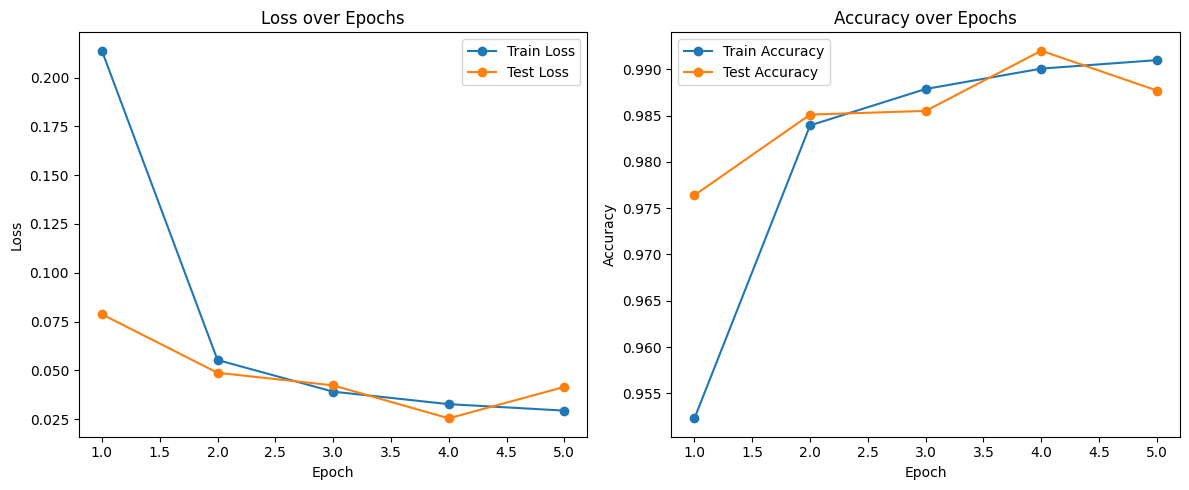

In [28]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, test_losses, label='Test Loss', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs, test_accuracies, label='Test Accuracy', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

### Make a Prediction

---



Once our model is trained, we can use it to make predictions. To do this, we first use our test set to predict the classes.

In [29]:
def show_random_predictions(model, dataset, num_images=5):
    model.eval()

    indices = random.sample(range(len(dataset)), num_images)
    images = torch.stack([dataset[i][0] for i in indices])
    labels = torch.tensor([dataset[i][1] for i in indices])

    images = images.to(DEVICE)
    outputs = model(images)
    preds = outputs.argmax(dim=1)

    plt.figure(figsize=(12, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.title(f"GT: {labels[i].item()}\nPred: {preds[i].item()}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Finally, we can show a random test image with its corresponding prediction.

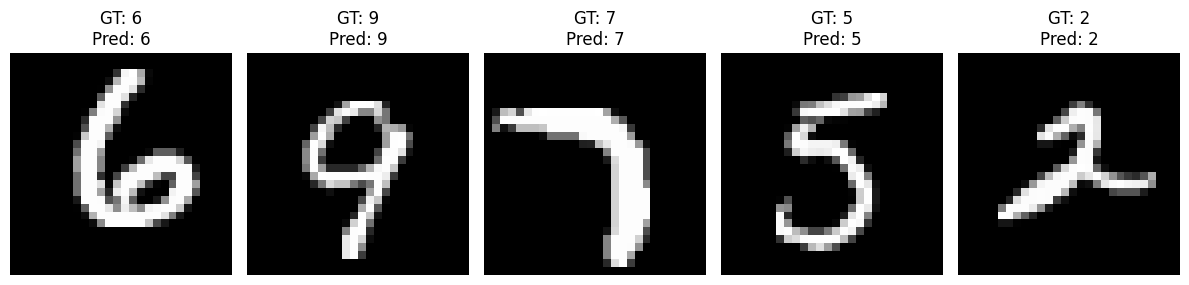

In [30]:
show_random_predictions(model, test_dataset, num_images=5)

# 다른 데이터셋으로도 진행해보기

---
# 코드과제 2

# [Week 2] Object Detection 실습 : YOLOv1 구현하기 (Assignment)

이번 과제는 **PascalVOC 데이터셋**을 사용하여 **YOLOv1** 모델을 밑바닥부터(Scratch) 구현해보는 것입니다.

**목표**:
1. YOLOv1의 **CNN 아키텍처**를 직접 구현합니다.
2. YOLOv1의 핵심인 **Loss Function** (Localization, Confidence, Class Probability)을 구현합니다.
3. PascalVOC 데이터셋으로 모델을 학습시키고 결과를 확인합니다.

**참고**:
- Colab에서 실행 시 **런타임 > 런타임 유형 변경 > 하드웨어 가속기**를 **GPU**로 설정해주세요.
---

In [31]:
## 1. Import Statements

import os, subprocess
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.notebook import tqdm
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.transforms.functional as FT
from sklearn.model_selection import train_test_split

# GPU 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## 2. Data Preprocessing (PascalVOC)

Kaggle에서 PascalVOC 데이터셋을 다운로드합니다.

In [32]:
import kagglehub, os, shutil

try:
    path = kagglehub.dataset_download("aladdinpersson/pascalvoc-yolo")
    dst  = "/content/data"
    os.makedirs(dst, exist_ok=True)

    # 데이터셋 이동 (Colab 환경 가정)
    if os.path.exists(dst) and not os.listdir(dst):
        subprocess.run(["mv", f"{path}/*", dst], shell=True, check=True)
        final_path = dst
    else:
        final_path = path # 로컬 등 다른 환경일 경우

    print(f"Data Path: {final_path}")
except Exception as e:
    print(f"Error downloading/moving data: {e}")
    # 로컬 테스트용 경로 설정 (필요 시 수정)
    final_path = "./data/pascalvoc-yolo"

# 경로 설정
img_dir = os.path.join(final_path, "images")
label_dir = os.path.join(final_path, "labels")
total_train_csv = os.path.join(final_path, "train.csv")
test_csv = os.path.join(final_path, "test.csv")

# Train/Valid Split
if os.path.exists(total_train_csv):
    df = pd.read_csv(total_train_csv)
    train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)
    train_df.to_csv("train.csv", index=False)
    val_df.to_csv("valid.csv", index=False)
else:
    print("Warning: train.csv not found. Check dataset path.")

100%|██████████| 4.31G/4.31G [04:04<00:00, 18.9MB/s]

Extracting files...


Data Path: /root/.cache/kagglehub/datasets/aladdinpersson/pascalvoc-yolo/versions/1


## 3. Model Implementation (YOLOv1)

YOLOv1의 아키텍처를 구현합니다. 논문에 나온 구조를 참고하여 `CNNBlock`과 `Yolov1` 클래스를 완성하세요.

### [TODO 1] YOLOv1 모델 구조 구현

In [ ]:
# YOLOv1 Architecture Configuration
architecture_config = [
    (7, 64, 2, 3), # (kernel_size, num_filters, stride, padding)
    "M",           # MaxPool
    (3, 192, 1, 1),
    "M",
    (1, 128, 1, 0),
    (3, 256, 1, 1),
    (1, 256, 1, 0),
    (3, 512, 1, 1),
    "M",
    [(1, 256, 1, 0), (3, 512, 1, 1), 4], # [Tuple1, Tuple2, repeat]
    (1, 512, 1, 0),
    (3, 1024, 1, 1),
    "M",
    [(1, 512, 1, 0), (3, 1024, 1, 1), 2],
    (3, 1024, 1, 1),
    (3, 1024, 2, 1),
    (3, 1024, 1, 1),
    (3, 1024, 1, 1),
]

class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs): # kwargs로 나머지 인자들 한 번에
        super(CNNBlock, self).__init__()
        # -------------------------
        # [TODO] Conv2d -> BatchNorm2d -> LeakyReLU(0.1) 순서로 레이어 정의
        # 힌트: bias는 BatchNorm을 사용할 경우 False로 설정하는 것이 일반적입니다.

        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.batchnorm = nn.BatchNorm2d(out_channels)
        self.leakyrelu = nn.LeakyReLU(0.1)
        # -------------------------

    def forward(self, x):
        # [TODO] Forward pass 구현
        return self.leakyrelu(self.batchnorm(self.conv(x)))

class Yolov1(nn.Module):
    def __init__(self, in_channels=3, **kwargs):
        super(Yolov1, self).__init__()
        self.architecture = architecture_config
        self.in_channels = in_channels

        # [TODO] Darknet (Conv Layers) 생성
        self.darknet = self._create_conv_layers(self.architecture)

        # [TODO] Fully Connected Layers 생성
        self.fcs = self._create_fcs(**kwargs)

    def forward(self, x):
        # [TODO] Forward Pass 구현
        # 1. Darknet 통과
        # 2. Flatten
        # 3. FC Layers 통과
        x = self.darknet(x)
        # FC layer 안의 Flatten에서 batch 차원을 제외하고 한 줄로 펴줌
        return self.fcs(x)

    def _create_conv_layers(self, architecture):
        layers = []
        in_channels = self.in_channels

        for x in architecture:
            if type(x) == tuple:
                # (kernel_size, num_filters, stride, padding)
                # [TODO] CNNBlock 추가
                # 각 변수들에 x 할당
                kernel_size, out_channels, stride, padding = x
                layers.append(
                    CNNBlock(
                        in_channels, out_channels,kernel_size=kernel_size, stride=stride, padding=padding
                    )
                )
                # 다음 convolution은 지금 만든 filter 수를 입력 채널로 받음
                in_channels = out_channels
            elif type(x) == str:
                # "M" -> MaxPool
                # [TODO] MaxPool2d 추가
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            elif type(x) == list:
                # [Tuple1, Tuple2, repeat]
                # [TODO] 반복되는 블록 추가
                conv1, conv2, num_repeats = x
                for _ in range(num_repeats):
                    for kernel_size, out_channels, stride, padding in (conv1, conv2):
                        layers.append(
                            CNNBlock(
                                in_channels, out_channels,
                                kernel_size=kernel_size, stride=stride, padding=padding
                            )
                        )
                        in_channels = out_channels

        return nn.Sequential(*layers)

    def _create_fcs(self, split_size, num_boxes, num_classes):
        # YOLOv1의 마지막 FC Layer 구조: Flatten -> FC(4096) -> LeakyReLU -> FC(S*S*(C+B*5))
        S, B, C = split_size, num_boxes, num_classes

        # [TODO] Sequential 모델로 FC Layer 구성
        return nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024 * S * S, 4096),
            nn.LeakyReLU(0.1),
            nn.Linear(4096, S * S * (C + B * 5)),
        )

## 4. Loss Function Implementation

YOLOv1 Loss는 5개의 부분으로 구성됩니다:
1. **Coordinate Loss** (Box Center x, y)
2. **Coordinate Loss** (Box Width, Height - Sqrt 적용)
3. **Object Confidence Loss** (객체가 있을 때)
4. **No Object Confidence Loss** (객체가 없을 때)
5. **Class Probability Loss**

### [TODO 2] YOLOv1 Loss 함수 구현

In [ ]:
class YoloLoss(nn.Module):
    def __init__(self, S=7, B=2, C=20):
        super(YoloLoss, self).__init__()
        self.mse = nn.MSELoss(reduction="sum")
        self.S = S
        self.B = B
        self.C = C
        self.lambda_noobj = 0.5
        self.lambda_coord = 5

    def forward(self, predictions, target):
        # predictions shape: (BATCH_SIZE, S*S*(C+B*5))
        # target shape: (BATCH_SIZE, S, S, C+5)
        predictions = predictions.reshape(-1, self.S, self.S, self.C + self.B * 5)

        # ------------------------------------------------------
        # 1. IoU 계산 및 Responsible Box 찾기
        # ------------------------------------------------------
        # predictions[..., 21:25] -> Box 1 (x, y, w, h)
        # predictions[..., 26:30] -> Box 2 (x, y, w, h)

        # [TODO] 각 박스와 Target 박스 간의 IoU 계산
        iou_b1 = intersection_over_union(predictions[..., 21:25], target[..., 21:25])
        iou_b2 = intersection_over_union(predictions[..., 26:30], target[..., 21:25])

        # [TODO] 두 박스 중 IoU가 더 높은 박스를 선택 (Responsible Box)
        ious = torch.cat((iou_b1, iou_b2), dim=-1)
        _, best_box = torch.max(ious, dim=-1, keepdim=True)
        best_box = best_box.float() # box 2가 responsible이면 1, 아니면 0
        exists_box = target[..., 20:21] # 해당 cell에 object가 있는지 표시

        # ------------------------------------------------------
        # 2. Box Coordinates Loss
        # ------------------------------------------------------
        # [TODO] Box 좌표 (x, y, w, h)에 대한 MSE Loss 계산
        # 주의: w, h는 sqrt를 취한 후 차이를 구해야 함

        # best_box 값으로 두 prediction 중 responsible box의 좌표만 고름
        box_predictions = (1 - best_box) * predictions[..., 21:25] + best_box * predictions[..., 26:30]
        box_predictions = exists_box * box_predictions
        box_targets = exists_box * target[..., 21:25]

        # 큰 box의 오차가 지나치게 커지지 않도록 w, h에는 sqrt 적용
        pred_xy = box_predictions[..., 0:2]
        pred_wh = torch.sign(box_predictions[..., 2:4]) * torch.sqrt(
            torch.abs(box_predictions[..., 2:4]) + 1e-6
        )
        target_xy = box_targets[..., 0:2]
        target_wh = torch.sqrt(torch.clamp(box_targets[..., 2:4], min=0))

        box_loss = self.mse(
            torch.cat((pred_xy, pred_wh), dim=-1),
            torch.cat((target_xy, target_wh), dim=-1),
        )

        # ------------------------------------------------------
        # 3. Object Loss
        # ------------------------------------------------------
        # [TODO] 객체가 있는 셀의 Confidence Score에 대한 Loss

        pred_confidence = (1 - best_box) * predictions[..., 20:21] + best_box * predictions[..., 25:26]
        object_loss = self.mse(
            exists_box * pred_confidence,
            exists_box * target[..., 20:21],
        )

        # ------------------------------------------------------
        # 4. No Object Loss
        # ------------------------------------------------------
        # [TODO] 객체가 없는 셀(및 Responsible이 아닌 박스)의 Confidence Loss

        # object가 없는 cell의 두 box와, object가 있어도 responsible이 아닌 box가 대상
        responsible_b1 = exists_box * (1 - best_box)
        responsible_b2 = exists_box * best_box
        noobj_b1 = 1 - responsible_b1
        noobj_b2 = 1 - responsible_b2

        no_object_loss = self.mse(
            noobj_b1 * predictions[..., 20:21],
            torch.zeros_like(predictions[..., 20:21]),
        )
        no_object_loss += self.mse(
            noobj_b2 * predictions[..., 25:26],
            torch.zeros_like(predictions[..., 25:26]),
        )

        # ------------------------------------------------------
        # 5. Class Loss
        # ------------------------------------------------------
        # [TODO] Class Probability에 대한 Loss

        class_loss = self.mse(
            exists_box * predictions[..., :self.C],
            exists_box * target[..., :self.C],
        )

        loss = (
            self.lambda_coord * box_loss
            + object_loss
            + self.lambda_noobj * no_object_loss
            + class_loss
        )

        return loss

## 5. Utils (IoU, NMS, mAP)

Object Detection에 필요한 유틸리티 함수들입니다. (이미 구현되어 있음)

In [ ]:
def intersection_over_union(boxes_preds, boxes_labels, box_format="midpoint"):
    # ... (생략된 IoU 코드, 실제로는 이 셀에 전체 코드를 넣어야 함) ...
    if box_format == "midpoint":
        box1_x1 = boxes_preds[..., 0:1] - boxes_preds[..., 2:3] / 2
        box1_y1 = boxes_preds[..., 1:2] - boxes_preds[..., 3:4] / 2
        box1_x2 = boxes_preds[..., 0:1] + boxes_preds[..., 2:3] / 2
        box1_y2 = boxes_preds[..., 1:2] + boxes_preds[..., 3:4] / 2
        box2_x1 = boxes_labels[..., 0:1] - boxes_labels[..., 2:3] / 2
        box2_y1 = boxes_labels[..., 1:2] - boxes_labels[..., 3:4] / 2
        box2_x2 = boxes_labels[..., 0:1] + boxes_labels[..., 2:3] / 2
        box2_y2 = boxes_labels[..., 1:2] + boxes_labels[..., 3:4] / 2
    elif box_format == "corners":
        box1_x1, box1_y1, box1_x2, box1_y2 = boxes_preds[..., 0:1], boxes_preds[..., 1:2], boxes_preds[..., 2:3], boxes_preds[..., 3:4]
        box2_x1, box2_y1, box2_x2, box2_y2 = boxes_labels[..., 0:1], boxes_labels[..., 1:2], boxes_labels[..., 2:3], boxes_labels[..., 3:4]

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
    box1_area = torch.abs((box1_x2 - box1_x1) * (box1_y2 - box1_y1))
    box2_area = torch.abs((box2_x2 - box2_x1) * (box2_y2 - box2_y1))

    return intersection / (box1_area + box2_area - intersection + 1e-6)

def non_max_suppression(bboxes, iou_threshold, threshold, box_format="midpoint"):
    assert type(bboxes) == list

    bboxes = [box for box in bboxes if box[1] > threshold]
    bboxes = sorted(bboxes, key=lambda x: x[1], reverse=True)
    bboxes_after_nms = []

    while bboxes:
        chosen_box = bboxes.pop(0)

        bboxes = [
            box
            for box in bboxes
            if box[0] != chosen_box[0]
            or intersection_over_union(
                torch.tensor(chosen_box[2:]),
                torch.tensor(box[2:]),
                box_format=box_format,
            )
            < iou_threshold
        ]

        bboxes_after_nms.append(chosen_box)

    return bboxes_after_nms

# mAP 함수 등 나머지 Utils는 생략 없이 포함되어야 하지만 지면 관계상 핵심만 보여드립니다.
def mean_average_precision(pred_boxes, true_boxes, iou_threshold=0.5, box_format="midpoint", num_classes=20):
    # ... (mAP 구현 코드) ...
    return 0.0 # Placeholder

## 6. Training Loop

모델을 학습시키는 Loop입니다.

In [ ]:
class VOCDataset(Dataset):
    # ... (Dataset 구현 코드, Solution 파일 참조하여 복사 필요) ...
    pass

def train_fn(train_loader, model, optimizer, loss_fn):
    # ... (Training Function) ...
    pass

def main():
    model = Yolov1(split_size=7, num_boxes=2, num_classes=20).to(device)
    optimizer = optim.Adam(model.parameters(), lr=2e-5, weight_decay=0)
    loss_fn = YoloLoss()

    # ... (DataLoader 및 학습 Loop) ...

if __name__ == "__main__":
    # main()
    pass